In [1]:
from py_files.setup import *
setup_notebook()

import py_files.elas as elas
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Effect of $\varepsilon^S$ and $\phi$ on `wages` and `welfare`

**Goal:** Describe effect of the `capital supply elasticity` and of the friction of moving between sectors, i.e.
\begin{align*}
    &\frac{d\log w_C}{d\log (1-\tau_t)}(\varepsilon^S), \quad
    \frac{d\log w_I}{d\log (1-\tau_t)}(\varepsilon^S), \quad
    \frac{d\log r_K}{d\log (1-\tau_t)}(\varepsilon^S), \quad \\
    &\frac{d\log w_C}{d\log (1-\tau_t)}(\varepsilon^S(\phi)), \quad
    \frac{d\log w_I}{d\log (1-\tau_t)}(\varepsilon^S(\phi)), \quad
    \frac{d\log r_K}{d\log (1-\tau_t)}(\varepsilon^S(\phi)), \quad 
\end{align*}
To discuss the effect of the `capital supply elasticity` and relation to NCM, through *Chamley-Judd*.

**Output:**

1. Plot the wage/rent effects in $(w_I/r_K, \varepsilon^S)$.
2. Plot the wage/rent effects in $(w_I/r_K, \phi)$.
3. Do the simulation for some chosen elasticities.

*`1. prep`*

In [2]:
m = CapIncModel_single()
out = m.calibrate()


 Calibrate household: zero wage premia + target eps_nI 
targets    prem1=0, prem2=0, eps1=1.0
------------------------------------------------------------
old        mu1=0.26   =>
           log(w1I/w1C)=-1.07e-01

old        phi1=0.30 =>
           eps1=0.224
------------------------------------------------------------
new        mu1=0.2340   =>
           log(w1I/w1C)=-2.08e-13

new        phi1=1.3056 =>
           eps1=1.000



*`2. welfare incidence`*

In [60]:
# 1. set up
T=25; tau0=0.0; rho=0.85; tail=50; tau_ss=0.0 
ss0 = m.solve_steady_state(tau=tau0)

# 2. params and sim 
# 2.1 temp
# tauT = 0.0
# net_long, tau_long, dlog_net_long, tauT = shocks.temp_tc(
#     T=T, tail=tail,
# )
# sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)
# fig, (ax1, ax2), ss, sim = build_output_single.welfare_effects(
#     m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
# )
# plt.close(fig)

# 2.2 perm
tauT = -0.1
net_long, tau_long, dlog_net_long, tauT = shocks.perm_tc(
    T=T, tau0=tau0, tauT=tauT, rho=rho, tail=tail,
)
sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)
fig, (ax1, ax2), ss, sim = build_output_single.welfare_effects(
    m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
)
plt.close(fig)

# 3. compute welfare incidence
welf = elas.welfare_incidence(sim)

*`3. elasticities`*

In [61]:
out_base = elas.dem_sup_elas(m, tau=0.0)
epsD_baseline = out_base['epsD']

print(f"Baseline epsD    = {epsD_baseline:.4f}")
print(f"Baseline epsS_LR = {out_base['epsS_LR']:.4f}")
print(f"Baseline epsS_SR = {out_base['epsS_SR']:.4f}")

epsS_grid = np.linspace(0.01, 20, 2000)

w_C_S, w_I_S, r_K_S = [], [], []
for epsS in epsS_grid:
    res = elas.wr_tax_elas(m, elas_out=out_base, epsS_LR=epsS)
    w_C_S.append(res['w_C_elas'])
    w_I_S.append(res['w_I_elas'])
    r_K_S.append(res['r_K_elas'])

w_C_S = np.array(w_C_S)
w_I_S = np.array(w_I_S)
r_K_S = np.array(r_K_S)

total_S    = w_C_S + w_I_S + r_K_S
share_wC_S = w_C_S / total_S * 100
share_wI_S = w_I_S / total_S * 100
share_rK_S = r_K_S / total_S * 100
epsS_base  = out_base['epsS_LR']

Baseline epsD    = 1.4798
Baseline epsS_LR = 1.7417
Baseline epsS_SR = 0.1365


*`4. $\phi$`*

In [62]:
# ── epsS sweep (marginal) ─────────────────────────────────────────────────────
# out_base  = elas.dem_sup_elas(m, tau=0.0)
# epsS_base = out_base['epsS_LR']
# epsS_grid = np.linspace(0.01, 20, 2000)

w_C_S, w_I_S, r_K_S = [], [], []
for epsS in epsS_grid:
    res = elas.wr_tax_elas(m, elas_out=out_base, epsS_LR=epsS)
    w_C_S.append(res['w_C_elas'])
    w_I_S.append(res['w_I_elas'])
    r_K_S.append(res['r_K_elas'])

w_C_S, w_I_S, r_K_S = np.array(w_C_S), np.array(w_I_S), np.array(r_K_S)
total_S    = w_C_S + w_I_S + r_K_S
share_wC_S = w_C_S / total_S * 100
share_wI_S = w_I_S / total_S * 100
share_rK_S = r_K_S / total_S * 100

# ── phi sweep — MARGINAL (price elasticity) ───────────────────────────────────
phi_grid = np.linspace(0.01, 20, 2000)
phi_base = 0.3

w_C_Pm, w_I_Pm, r_K_Pm = [], [], []
for phi in phi_grid:
    m.phi1 = phi
    out = elas.dem_sup_elas(m, tau=0.0)
    res = elas.wr_tax_elas(m, elas_out=out, epsD=out['epsD'])
    w_C_Pm.append(res['w_C_elas'])
    w_I_Pm.append(res['w_I_elas'])
    r_K_Pm.append(res['r_K_elas'])

m.phi1 = 1.35

w_C_Pm, w_I_Pm, r_K_Pm = np.array(w_C_Pm), np.array(w_I_Pm), np.array(r_K_Pm)
total_Pm    = w_C_Pm + w_I_Pm + r_K_Pm
share_wC_Pm = w_C_Pm / total_Pm * 100
share_wI_Pm = w_I_Pm / total_Pm * 100
share_rK_Pm = r_K_Pm / total_Pm * 100

# ── phi sweep — WELFARE (full simulation) ────────────────────────────────────
phi_grid_welf = np.linspace(0.01, 20, 100)

w_C_Pw, w_I_Pw, r_K_Pw = [], [], []
for phi in phi_grid_welf:
    m.phi1 = phi
    sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)
    _, _, _, sim = build_output_single.welfare_effects(
        m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
    )
    plt.close('all')
    welf  = elas.welfare_incidence(sim)
    total = welf['consump_w'] + welf['investm_w'] + welf['capital_o']
    w_C_Pw.append(welf['consump_w'] / total * 100)
    w_I_Pw.append(welf['investm_w'] / total * 100)
    r_K_Pw.append(welf['capital_o'] / total * 100)

m.phi1 = 1.35

w_C_Pw, w_I_Pw, r_K_Pw = np.array(w_C_Pw), np.array(w_I_Pw), np.array(r_K_Pw)
total_Pw    = w_C_Pw + w_I_Pw + r_K_Pw
share_wC_Pw = w_C_Pw / total_Pw * 100
share_wI_Pw = w_I_Pw / total_Pw * 100
share_rK_Pw = r_K_Pw / total_Pw * 100

*`5. plot`*

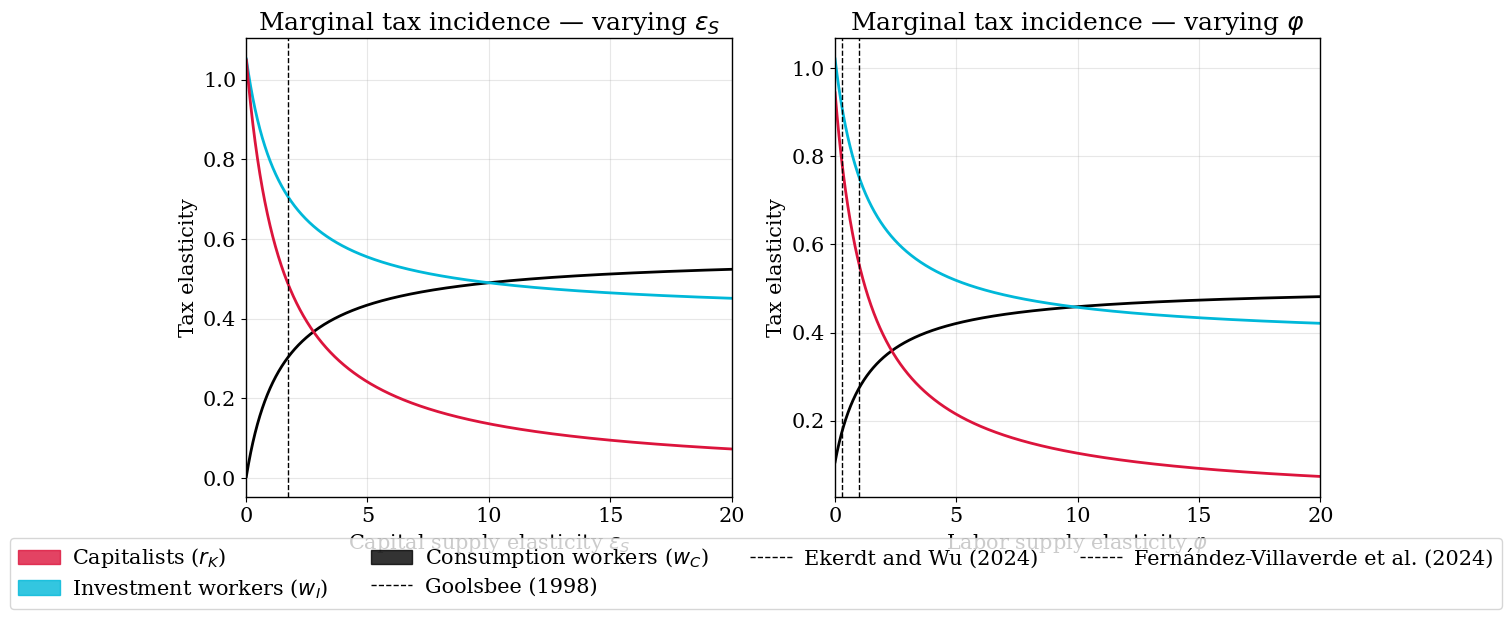

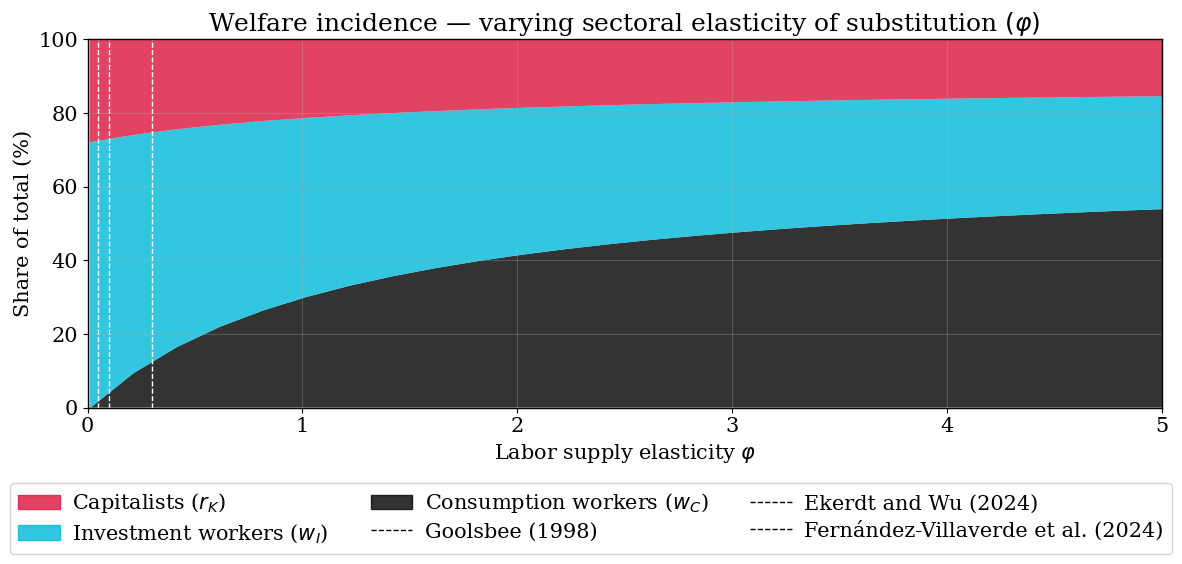


── epsS spot checks ──
epsS=    0.10  |  wC= 0.036  wI= 1.015  rK= 0.989  |  shares: 2% / 50% / 48%
epsS=    1.00  |  wC= 0.227  wI= 0.794  rK= 0.630  |  shares: 14% / 48% / 38%
epsS=    1.74  |  wC= 0.304  wI= 0.705  rK= 0.485  |  shares: 20% / 47% / 32%
epsS=   10.00  |  wC= 0.490  wI= 0.490  rK= 0.136  |  shares: 44% / 44% / 12%
epsS=   25.00  |  wC= 0.531  wI= 0.443  rK= 0.059  |  shares: 51% / 43% / 6%

── phi spot checks ──
phi= 0.10  epsD= 1.352  epsS= 0.410  |  wC= 0.131  wI= 0.982  rK= 0.887  |  shares: 7% / 49% / 44%
phi= 0.50  epsD= 1.393  epsS= 0.840  |  wC= 0.212  wI= 0.853  rK= 0.700  |  shares: 12% / 48% / 40%
phi= 0.30  epsD= 1.372  epsS= 0.625  |  wC= 0.176  wI= 0.909  rK= 0.782  |  shares: 9% / 49% / 42%
phi= 3.00  epsD= 1.644  epsS= 3.450  |  wC= 0.381  wI= 0.582  rK= 0.307  |  shares: 30% / 46% / 24%
phi=10.00  epsD= 2.286  epsS=10.116  |  wC= 0.459  wI= 0.457  rK= 0.126  |  shares: 44% / 44% / 12%


In [74]:
colors   = ['crimson', 'k', '#00B8D9']
legend_handles = [
    Patch(color=colors[0], alpha=0.8, label=r'Capitalists ($r_K$)'),
    Patch(color=colors[2], alpha=0.8, label=r'Investment workers ($w_I$)'),
    Patch(color=colors[1], alpha=0.8, label=r'Consumption workers ($w_C$)'),
    Line2D([0], [0], color='k', ls='--', lw=1, label='Baseline'),
]

# ── Figure 1: marginal elasticity lines ──────────────────────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 6))

ax = axes1[0]
ax.plot(epsS_grid, w_C_S, color=colors[1], lw=2)
ax.plot(epsS_grid, w_I_S, color=colors[2], lw=2)
ax.plot(epsS_grid, r_K_S, color=colors[0], lw=2)
ax.axvline(epsS_base, color='k', ls='--', lw=1)
ax.set_xlabel(r'Capital supply elasticity $\varepsilon_S$')
ax.set_ylabel('Tax elasticity')
ax.set_title(r'Marginal tax incidence — varying $\varepsilon_S$')
ax.set_xlim(0, 20)
ax.grid(True, alpha=0.3)

ax = axes1[1]
ax.plot(phi_grid, w_C_Pm, color=colors[1], lw=2)
ax.plot(phi_grid, w_I_Pm, color=colors[2], lw=2)
ax.plot(phi_grid, r_K_Pm, color=colors[0], lw=2)
ax.axvline(0.3, color='k', ls='--', lw=1)
ax.axvline(1.0, color='k', ls='--', lw=1)
ax.set_xlabel(r'Labor supply elasticity $\varphi$')
ax.set_ylabel('Tax elasticity')
ax.set_title(r'Marginal tax incidence — varying $\varphi$')
ax.set_xlim(0, 20)
ax.grid(True, alpha=0.3)

fig1.legend(handles=legend_handles, loc='lower center', ncol=4,
            bbox_to_anchor=(0.5, -0.05), frameon=True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

# ── Figure 2: welfare incidence (single panel) ───────────────────────────────
legend_handles = [
    Patch(color=colors[0], alpha=0.8, label=r'Capitalists ($r_K$)'),
    Patch(color=colors[2], alpha=0.8, label=r'Investment workers ($w_I$)'),
    Patch(color=colors[1], alpha=0.8, label=r'Consumption workers ($w_C$)'),
    Line2D([0], [0], color='k', ls='--', lw=1, label='Goolsbee (1998)'),
    Line2D([0], [0], color='k', ls='--', lw=1, label='Ekerdt and Wu (2024)'),
    Line2D([0], [0], color='k', ls='--', lw=1, label='Fernández-Villaverde et al. (2024)'),
]

fig2, ax2 = plt.subplots(1, 1, figsize=(12, 5))

ax2.stackplot(phi_grid_welf, share_wC_Pw, share_wI_Pw, share_rK_Pw,
              colors=[colors[1], colors[2], colors[0]], alpha=0.8)

ax2.axvline(0.1, color='white', ls='--', lw=1)
ax2.axvline(0.3, color='white', ls='--', lw=1)
ax2.axvline(0.05, color='white', ls='--', lw=1)

ax2.set_xlabel(r'Labor supply elasticity $\varphi$')
ax2.set_ylabel('Share of total (%)')
ax2.set_title(r'Welfare incidence — varying sectoral elasticity of substitution $(\varphi)$')
ax2.set_xlim(0, 5)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(plt.MultipleLocator(1))

fig2.legend(handles=legend_handles, loc='lower center', ncol=3,
            bbox_to_anchor=(0.5, -0.15), frameon=True)
plt.tight_layout()
plt.show()

# ── Spot checks ───────────────────────────────────────────────────────────────
print("\n── epsS spot checks ──")
for eps in [0.1, 1.0, epsS_base, 10, 25]:
    res = elas.wr_tax_elas(m, elas_out=out_base, epsS_LR=eps)
    tot = sum(res.values())
    print(f"epsS={eps:8.2f}  |  wC={res['w_C_elas']:6.3f}  wI={res['w_I_elas']:6.3f}  rK={res['r_K_elas']:6.3f}  |  shares: {res['w_C_elas']/tot*100:.0f}% / {res['w_I_elas']/tot*100:.0f}% / {res['r_K_elas']/tot*100:.0f}%")

print("\n── phi spot checks ──")
for phi in [0.1, 0.5, phi_base, 3.0, 10.0]:
    m.phi1 = phi
    out = elas.dem_sup_elas(m, tau=0.0)
    res = elas.wr_tax_elas(m, elas_out=out)
    tot = sum(res.values())
    print(f"phi={phi:5.2f}  epsD={out['epsD']:6.3f}  epsS={out['epsS_LR']:6.3f}  |  wC={res['w_C_elas']:6.3f}  wI={res['w_I_elas']:6.3f}  rK={res['r_K_elas']:6.3f}  |  shares: {res['w_C_elas']/tot*100:.0f}% / {res['w_I_elas']/tot*100:.0f}% / {res['r_K_elas']/tot*100:.0f}%")

m.phi1 = 1.35  # restore